In [3]:
pip install opendatasets --upgrade --quiet

In [4]:
import opendatasets as od
download_url = "https://www.kaggle.com/datasets/saadharoon27/diwali-sales-dataset"
od.download(download_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: himanshubhamaniya
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/saadharoon27/diwali-sales-dataset


100%|██████████| 213k/213k [00:00<00:00, 354kB/s]

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv("/content/diwali-sales-dataset/Diwali Sales Data.csv", encoding='latin1')

In [7]:
df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [9]:
df.drop(["Status","unnamed1"], axis = 1, inplace=True)

In [10]:
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [11]:
df.dropna(inplace=True)

In [12]:
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610858
std,12.753866,1.114967,5222.355869
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


#Exploratory Data Analysis

In [13]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

####Based on Gender

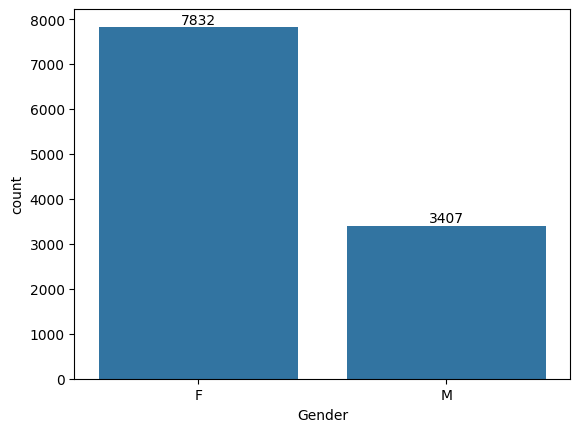

In [14]:
ax = sns.countplot(x = 'Gender', data = df)
for bars in ax.containers:
  ax.bar_label(bars)

,Gender,Amount
0,F,74335856.43
1,M,31913276.00


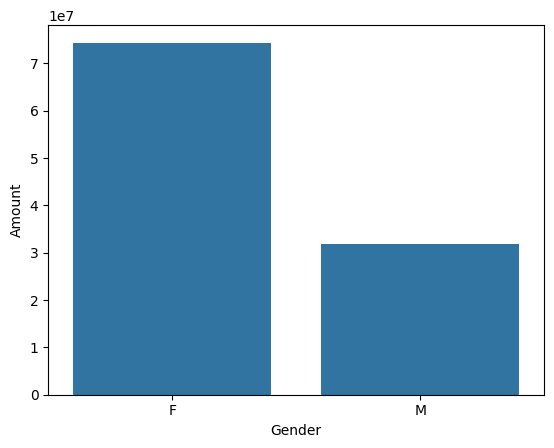

In [15]:
sales_gen=  df.groupby(['Gender'], as_index= False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.barplot(x="Gender", y="Amount",  data= sales_gen)
sales_gen


Acoording to the above graphs we see that number of female buyers is more than males and also the purchasing power of female buyer is more than male.




####Based on Age Group

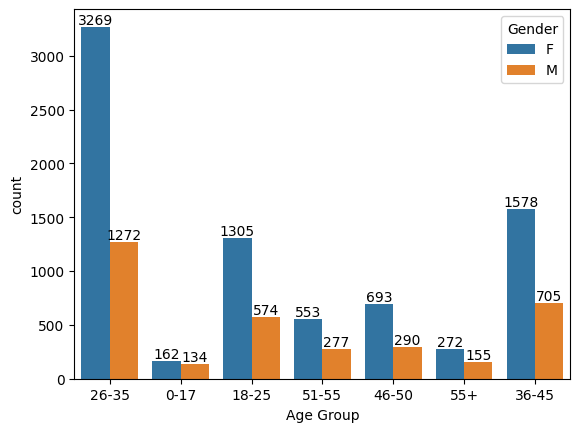

In [16]:
ax = sns.countplot(x = "Age Group" , data = df, hue= 'Gender')
for bars in ax.containers:
  ax.bar_label(bars)

,Age Group,Amount
2,26-35,42613443.94
3,36-45,22144995.49
1,18-25,17240732.00
4,46-50,9207844.00
5,51-55,8261477.00
6,55+,4080987.00
0,0-17,2699653.00


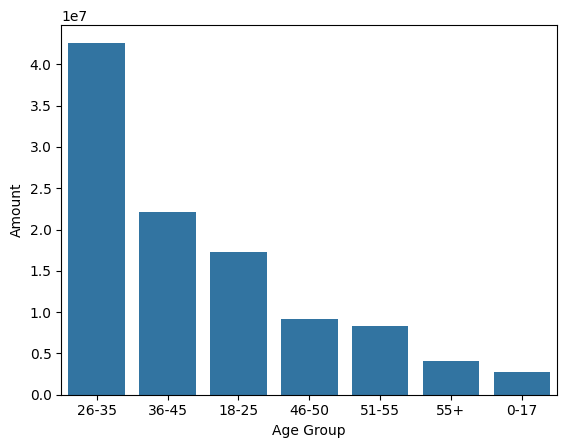

In [17]:
sales_age = df.groupby(['Age Group'], as_index = False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Age Group', y= 'Amount', data=sales_age)
sales_age

According to the above graphs we see that most of the buyers are from Age Group 26-35 years and are mostly females.

####Based on Region

<Axes: xlabel='State', ylabel='Orders'>

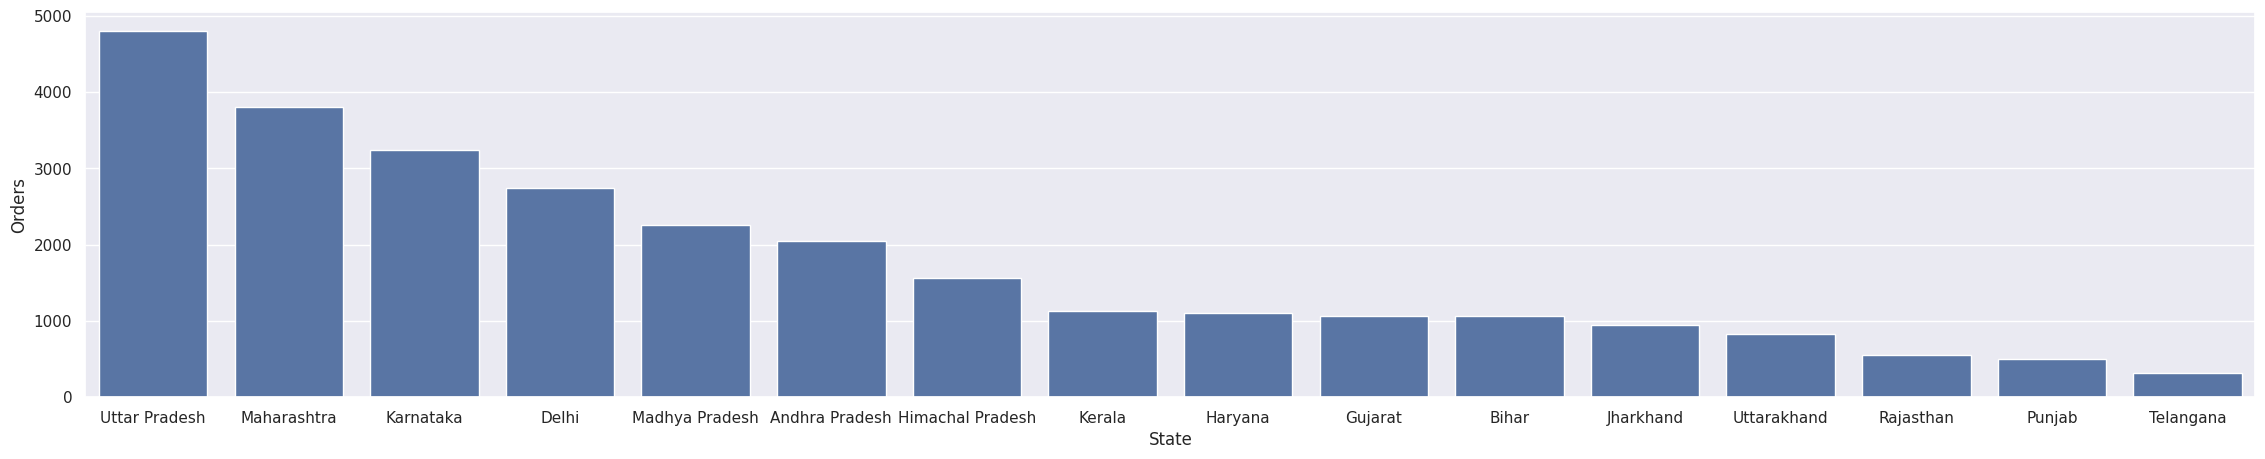

In [18]:
sales_state = df.groupby(['State'], as_index= False)['Orders'].sum().sort_values(by='Orders', ascending=False)
sns.set(rc={'figure.figsize':(28,5)})
sns.barplot(x= 'State', y='Orders', data=sales_state)

<Axes: xlabel='State', ylabel='Amount'>

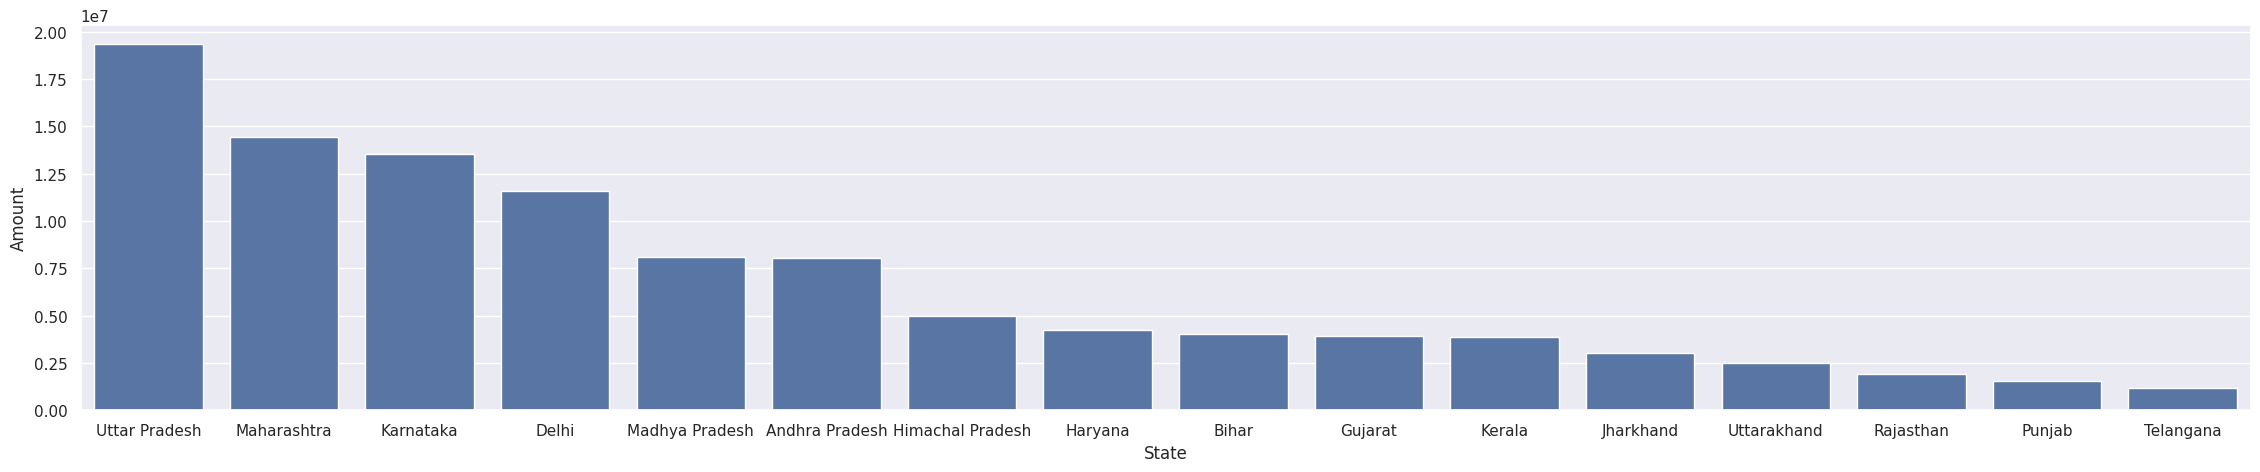

In [19]:
sales_state = df.groupby(['State'], as_index= False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.set(rc={'figure.figsize':(28,5)})
sns.barplot(x= 'State', y='Amount', data=sales_state)

According to the above graphs the Top three states with most numbers of orders is Uttar Pardesh, Maharastra and Karnataka respectively.

####Based on Marital Status

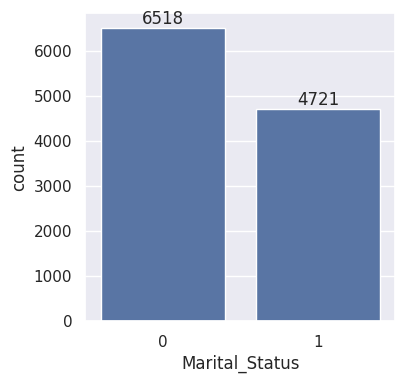

In [20]:
sns.set(rc={'figure.figsize':(4,4)})
ax = sns.countplot(x ='Marital_Status', data=df)
for bars in ax.containers:
  ax.bar_label(bars)

,Marital_Status,Gender,Amount
0,0,F,43786648.44
2,1,F,30549207.99
1,0,M,18338738.00
3,1,M,13574538.00


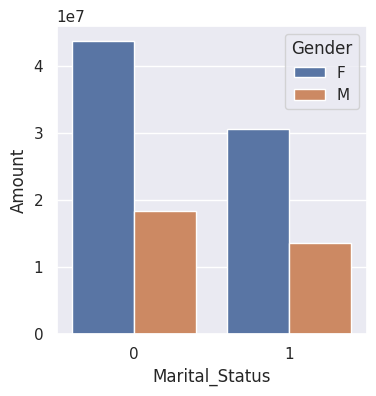

In [21]:
sales_mar = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Marital_Status', y='Amount', data=sales_mar, hue="Gender")
sales_mar

According to the above graphs we can say that Married (women) has high purchasing power.

####Based on Occupation

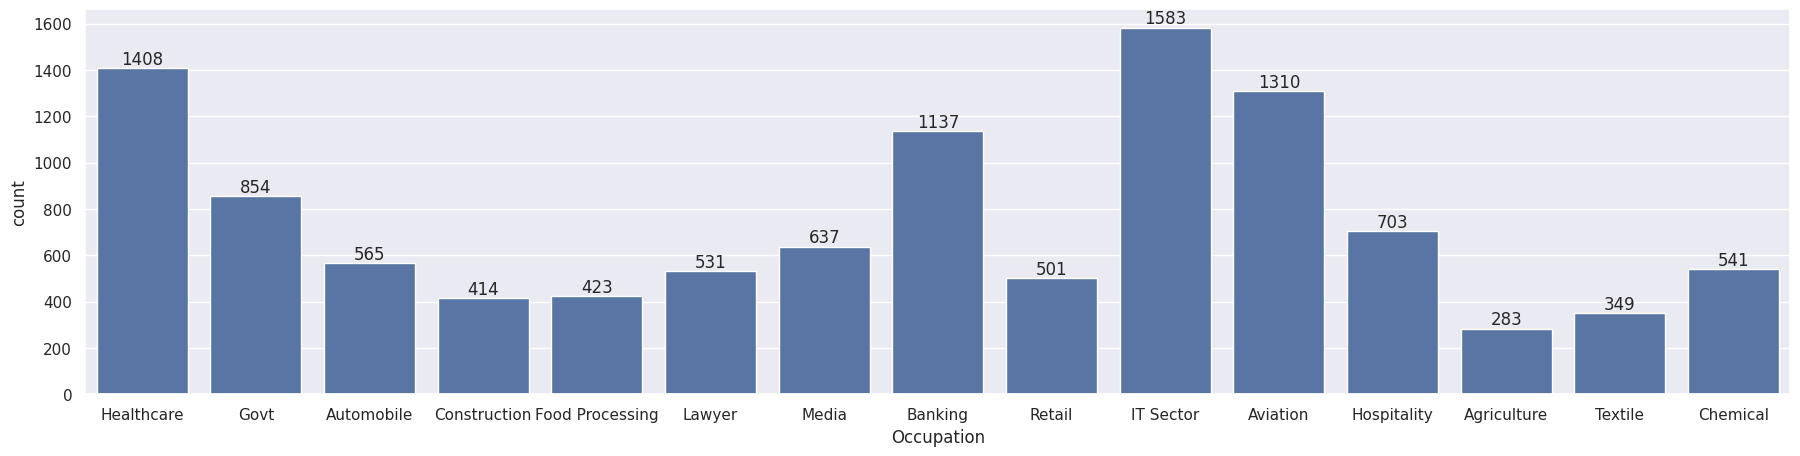

In [22]:
sns.set(rc={'figure.figsize':(22,5)})
ax = sns.countplot(x='Occupation', data=df)

for bars in ax.containers:
  ax.bar_label(bars)

,Occupation,Amount
10,IT Sector,14755079.00
8,Healthcare,13034587.49
2,Aviation,12602298.00


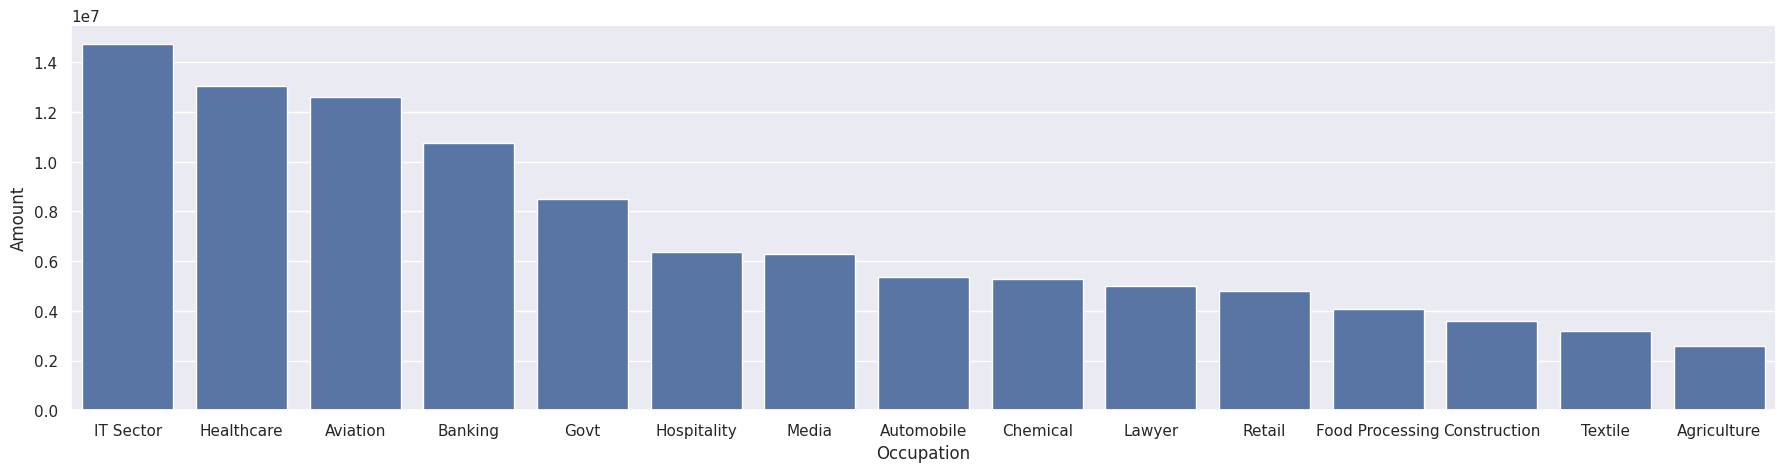

In [23]:
sales_occ = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Occupation', y='Amount', data=sales_occ)
sales_occ.head(3)

According to the above graphs the Top three Occupations that buyers are working in are IT Sector, Healthcare and Aviation respectively.

####Based on Product Category

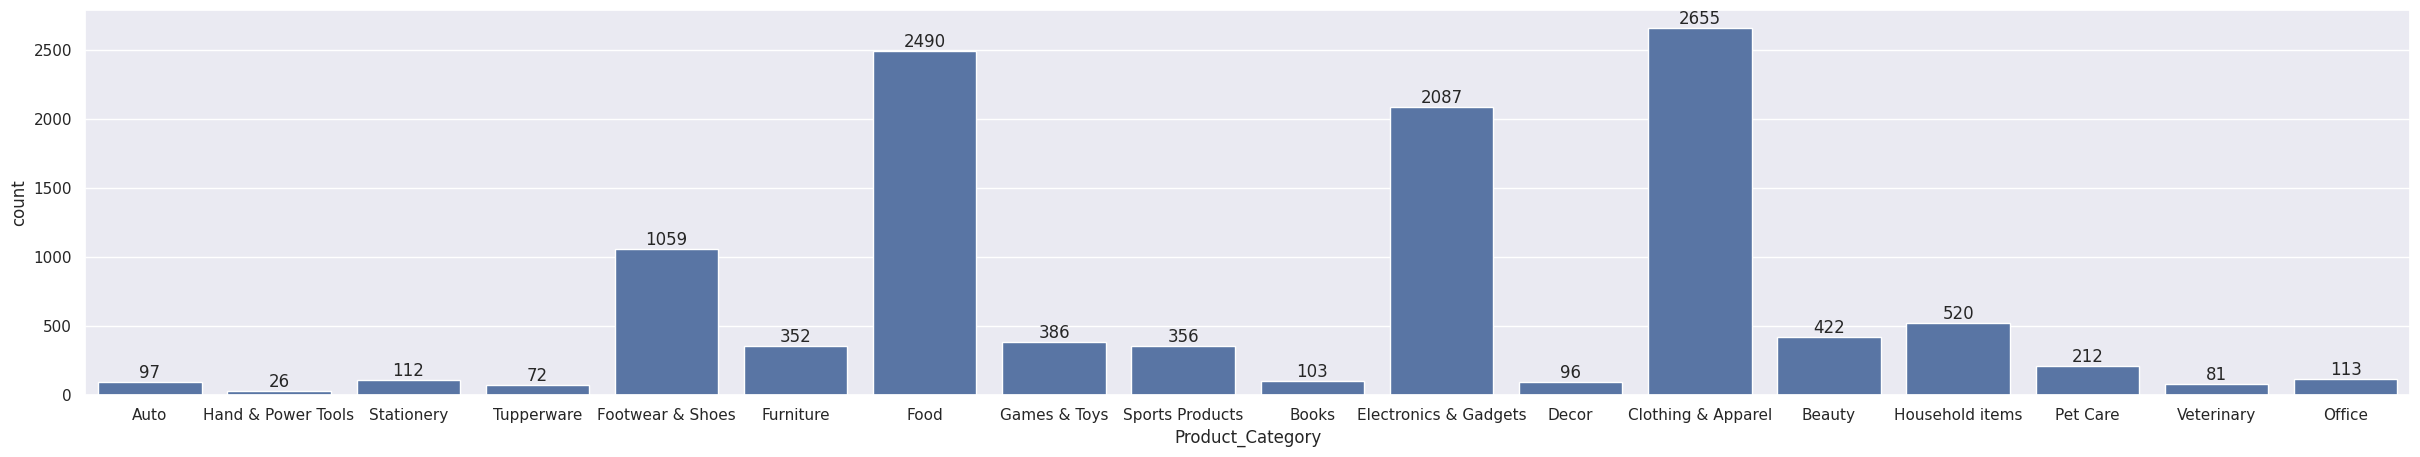

In [24]:
sns.set(rc={'figure.figsize':(30,5)})
ax = sns.countplot(x='Product_Category', data=df)
for bars in ax.containers:
  ax.bar_label(bars)

,Product_Category,Amount
6,Food,33933883.5
3,Clothing & Apparel,16495019.0
5,Electronics & Gadgets,15643846.0


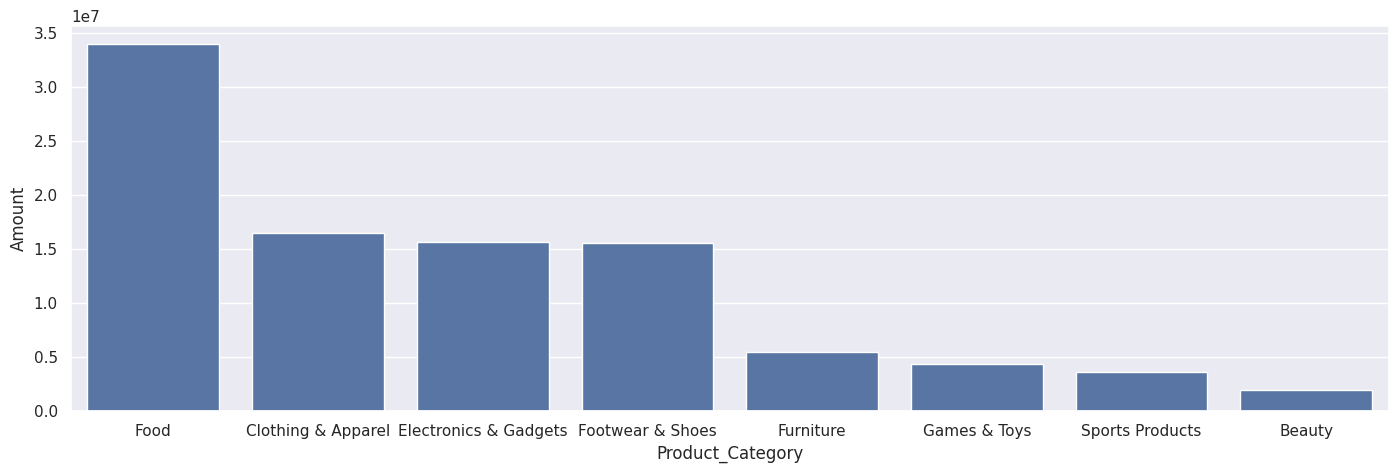

In [25]:
sns.set(rc={'figure.figsize':(17,5)})
sales_prod = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(8)
sns.barplot(x='Product_Category', y='Amount', data=sales_prod)
sales_prod.head(3)

According to above graphs the buyers have bought Clothing & Apparel products more than other products but the money or the amount was more spent on Food.

# Conclusion

According to the above Analysis we can say that Married Women of the Age Group 26-35 yrs from Uttar Pardesh, Maharastra and Karnataka how are working in IT Sector, Healthcare and Aviation are more likely to buy products like Food, Clothing & Apparel and Electronics & Gadgets.